- ####  <mark style="background-color: #db7390;">Car Price Prediction Project : (ML) </mark>


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

### Task 1: <mark style="background-color: #db7390;">Exploratory Data Analysis (EDA)</mark>

In this task, we explore the dataset to understand its structure, data types, missing values, and relationships between variables

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\Yahia\Downloads\car_price.csv")  

# Display first 5 rows
display(df.head())
display(df.tail())

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
72430,I30,2016.0,8680.0,Manual,25906.0,Diesel,0.0,78.4,1.6,Hyundai
72431,I40,2015.0,7830.0,Manual,NaN,Diesel,30.0,65.7,1.7,Hyundai
72432,I10,2017.0,6830.0,Manual,13810.0,Petrol,20.0,60.1,1.0,NaN
72433,Tucson,2018.0,13994.0,Manual,23313.0,Petrol,145.0,44.8,1.6,Hyundai
72434,Tucson,2016.0,15999.0,Automatic,11472.0,Diesel,125.0,57.6,1.7,Hyundai


### Dataset Shape

The dataset contains <mark style="background-color: #db7390;">72,435</mark> rows and <mark style="background-color: #db7390;">10</mark> columns, indicating a relatively large dataset suitable for analysis

In [3]:
# Check number of rows and columns
print("Dataset shape:", df.shape)
# Get data types of each column
df.dtypes

Dataset shape: (72435, 10)


model            object
year            float64
price           float64
transmission     object
mileage         float64
fuelType         object
tax             float64
mpg             float64
engineSize      float64
Make             object
dtype: object

### Data Types

The dataset includes both numerical and categorical features:

- <mark style="background-color: #db7390;">Numerical features</mark> : year, price, mileage, tax, mpg, engineSize

- <mark style="background-color: #db7390;">Categorical features</mark> : model, transmission, fuelType, Make

This distinction is important for choosing appropriate analysis and preprocessing techniques

In [4]:
# Separate numerical and categorical features
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features is: " , numerical_cols)
print("Categorical Features is: " , categorical_cols)


Numerical Features is:  ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
Categorical Features is:  ['model', 'transmission', 'fuelType', 'Make']


### Missing Values

The dataset contains a significant number of missing values across multiple columns.

- Total missing values: <mark style="background-color: #db7390;">36,216</mark>

- Rows containing missing values: <mark style="background-color: #db7390;">29,110</mark>

In [5]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)

# Total missing values
print("\nTotal missing values:", missing_values.sum())

# Display rows that contain any missing values
missing_rows = df[df.isnull().any(axis=1)]

print("\nNumber of rows with missing values:", missing_rows.shape[0])

display(missing_rows.head())  

Missing values in each column:


model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64


Total missing values: 36216

Number of rows with missing values: 29110


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
7,A4,2016.0,11750.0,NaN,75185.0,Diesel,20.0,70.6,2.0,audi
9,A1,2016.0,12000.0,Manual,22451.0,NaN,30.0,55.4,1.4,audi
11,A6,2016.0,16500.0,Automatic,52198.0,Diesel,NaN,57.6,2.0,audi
14,A6,2015.0,15400.0,NaN,47348.0,Diesel,30.0,61.4,2.0,NaN
15,A3,2017.0,14500.0,Automatic,26156.0,NaN,145.0,58.9,1.4,audi


### Price Distribution

The distribution of car prices is clearly <mark style="background-color: #db7390;">right-skewed</mark>, indicating that most cars fall within the lower to mid-price range.

- A large concentration of values is observed between approximately 5,000 and 20,000, while a small number of cars have significantly higher prices.
- The long tail on the right side suggests the presence of outliers, representing high-end or luxury vehicles.

This distribution implies that the majority of cars in the dataset are relatively affordable, with only a few expensive entries

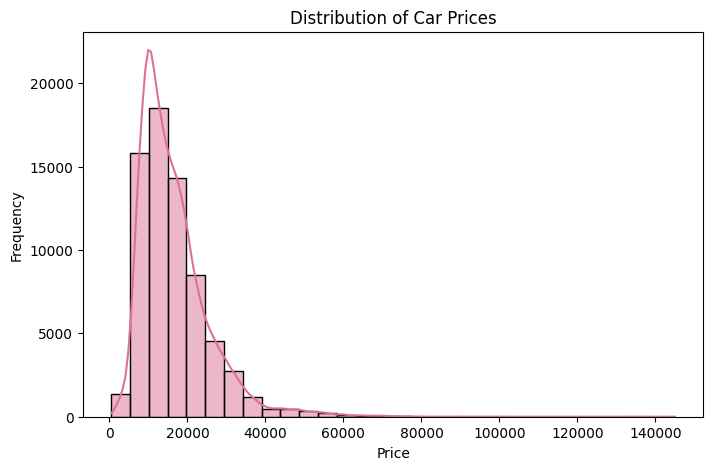

In [7]:
# Plot price distribution
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True, color="#db7390")

plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### Correlation with Price

Correlation analysis reveals the features most related to car price:

- <mark style="background-color: #db7390;">Engine size</mark> has the strongest positive correlation with price

- <mark style="background-color: #db7390;">Year</mark> is also positively correlated, indicating newer cars are more expensive

- <mark style="background-color: #db7390;">Mileage</mark> shows a negative correlation, meaning higher mileage reduces price

- <mark style="background-color: #db7390;">MPG</mark> also has a negative relationship with price

These relationships are consistent with real-world expectations and highlight the most influential factors affecting car prices

price         1.000000
engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64


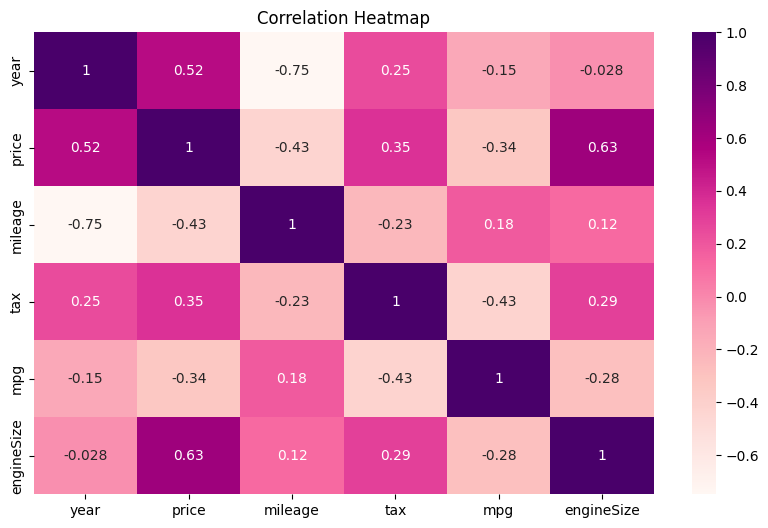

In [6]:
# Compute correlation matrix
# Correlation with price
corr = df.select_dtypes(include=np.number).corr()
print(corr['price'].sort_values(ascending=False))

# Heatmap visualization
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='RdPu')

plt.title("Correlation Heatmap")
plt.show()

In [7]:
top_features = corr['price'].sort_values(ascending=False)[1:5]
print(top_features)

engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
Name: price, dtype: float64


#### Task 3: <mark style="background-color: #db7390;">Creating Target Variables & Splitting

This step was performed before preprocessing <mark style="background-color: #db7390;">to clearly define the learning objectives for both regression and classification tasks.</mark>

Splitting the data before preprocessing <mark style="background-color: #db7390;">prevents data leakage</mark>, ensuring that information from the test set does not influence the training process.

This results in a more realistic evaluation of model performance.

###  Handling Missing Values in Target Variable
In this step, we focus on cleaning the **Target Variable (Price)** before proceeding to feature imputation. 

**Why drop missing values in the target instead of imputing them?**
- <mark style="background-color: #db7390;">Target Integrity</mark> : Imputing the price (e.g., using mean or median) can introduce significant bias and noise, leading to inaccurate model training

- <mark style="background-color: #db7390;">Model Learning</mark> : Since the goal of both Linear Regression and KNN is to learn the relationship between features and the actual price, training on "estimated" prices reduces the model's predictive power

- <mark style="background-color: #db7390;">Data Quality</mark> : Removing rows with missing labels ensures that the model is evaluated on real, observed data, which is crucial for achieving reliable $R^2$ and Accuracy metrics


In [8]:
#  Clean Target (Price)
print("=== Cleaning NaN in Target (price) ===")

print("Shape before cleaning:", df.shape)
print("NaN in price before:", df['price'].isna().sum())

# Drop rows where price is NaN
df = df.dropna(subset=['price']).reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("NaN in price after:", df['price'].isna().sum())

=== Cleaning NaN in Target (price) ===
Shape before cleaning: (72435, 10)
NaN in price before: 3621
Shape after cleaning: (68814, 10)
NaN in price after: 0


###  Classification Thresholds (Binning)
To convert the continuous price variable into discrete categories (**Cheap, Moderate, Expensive**), we used an automated statistical approach based on **Quantiles**.

**Why use Quantiles instead of fixed values?**
- <mark style="background-color: #db7390;">Balanced Classes</mark> : By using the 33rd and 66th percentiles, we ensure that the dataset is split into three roughly equal groups. This prevents "Class Imbalance," which could otherwise mislead the KNN model into favoring the most frequent category.

- <mark style="background-color: #db7390;">Data-Driven</mark> : The thresholds are derived directly from the distribution of our specific car dataset, making the categories representative of the actual market prices in the data.



In [9]:
# Calculate quantiles for splitting
low_threshold = df['price'].quantile(0.33)
high_threshold = df['price'].quantile(0.66)

print("Low Threshold (33%):", low_threshold)
print("High Threshold (66%):", high_threshold)

Low Threshold (33%): 11450.0
High Threshold (66%): 17995.0


**Threshold Results:**
- <mark style="background-color: #db7390;">Cheap</mark> : Price < Low Threshold.

- <mark style="background-color: #db7390;">Moderate</mark> : Low Threshold < Price < High Threshold.

- <mark style="background-color: #db7390;">Expensive</mark> : Price > High Threshold.

In [10]:


# Function to classify price into categories
def classify_price(price):
    if price <= low_threshold:
        return "Cheap"
    elif price <= high_threshold:
        return "Moderate"
    else:
        return "Expensive"

# Apply classification on cleaned dataset
df['price_category'] = df['price'].apply(classify_price)

# Preview results
df[['price', 'price_category']].head()

,price,price_category
0,12500.0,Moderate
1,16500.0,Moderate
2,11000.0,Cheap
3,16800.0,Moderate
4,17300.0,Moderate



**Class Distribution Summary:**
- <mark style="background-color: #db7390;">Expensive</mark> : ~23,172 cars

- <mark style="background-color: #db7390;">Moderate</mark> : ~22,927 cars

- <mark style="background-color: #db7390;">Cheap</mark> : ~22,715 cars


This balanced distribution is crucial for Task 5 (KNN), as it prevents the model from developing a bias toward any specific price range, ensuring that the **Accuracy** and **F1-score** represent the model's true predictive capability across the entire market.

In [11]:
df['price_category'].value_counts()

price_category
Expensive    23172
Moderate     22927
Cheap        22715
Name: count, dtype: int64

### Data Splitting for Model Training
Before training our models, we must split the dataset into two distinct sets: one for learning and another for evaluation.

**Why split the data?**
- <mark style="background-color: #db7390;">Generalization Check</mark> : It allows us to test the model on "unseen" data to see how it will perform in the real world.

- <mark style="background-color: #db7390;">Preventing Overfitting</mark> : If we train and test on the same data, the model might just "memorize" the answers instead of learning the underlying patterns.

**Implementation Details:**
- <mark style="background-color: #db7390;">Training Set (80%)</mark> : Used to fit the Linear Regression and KNN models. 

- <mark style="background-color: #db7390;">Testing Set (20%)</mark> : Kept aside to calculate metrics like $R^2$, MAE, and Accuracy.

- <mark style="background-color: #db7390;">(X)</mark> : All columns except `price` and `price_category`.

- <mark style="background-color: #db7390;">(y)</mark> : The `price` column for regression.

**Set Sizes:**
- <mark style="background-color: #db7390;">Training instances</mark> : 55,051 rows.

- <mark style="background-color: #db7390;">Testing instances</mark> : 13,763 rows.

In [12]:
# Target variable for regression (price)
y = df['price']

# Feature matrix (exclude price column)
X = df.drop(['price','price_category'], axis=1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42

)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (55051, 9)
Testing set size: (13763, 9)


### Feature Identification by Data Type
To apply the appropriate preprocessing transformations, we automatically separate our features into two categories based on their data types:

- <mark style="background-color: #db7390;">1. Numerical Features</mark> :

These features will undergo **Scaling** and **Outlier Handling.

- <mark style="background-color: #db7390;">2. Categorical Features</mark> :

These features will be processed using **One-Hot Encoding** to convert textual labels into a machine-readable format.


In [13]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print (cat_cols)

['year', 'mileage', 'tax', 'mpg', 'engineSize']
['model', 'transmission', 'fuelType', 'Make']


#### Task 2 : <mark style="background-color: #db7390;"> Preprocessing</mark>

Data preprocessing was applied after defining the target variables to ensure consistent transformations across both regression and classification tasks.


### Outlier Handling using IQR Method
To ensure our models are not misled by extreme values (Outliers), we implemented a **Capping (Clipping)** strategy using the Interquartile Range (IQR) method.

- <mark style="background-color: #db7390;">Why handle outliers?</mark>

Linear Regression Sensitivity: Extreme values can disproportionately pull the regression line, leading to a lower $R^2$ and higher error.

KNN Distance Calculation: Since KNN relies on Euclidean or Manhattan distances, outliers can distort the distance metrics, causing incorrect classifications.

- <mark style="background-color: #db7390;">Implementation Strategy</mark> :
1. **Identify Boundaries:** We calculate the lower and upper bounds for each numerical feature in the **Training Set**.
2. **Clipping:** Values falling outside $[Q1 - 1.5 \times IQR, Q3 + 1.5 \times IQR]$ are capped at these limits.
3. **Consistency:** We apply the **Training bounds** to the **Testing set** to maintain strict data separation and prevent data leakage.


In [14]:
for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    X_train[col] = np.clip(X_train[col], lower_bound, upper_bound)
    
    X_test[col] = np.clip(X_test[col], lower_bound, upper_bound)

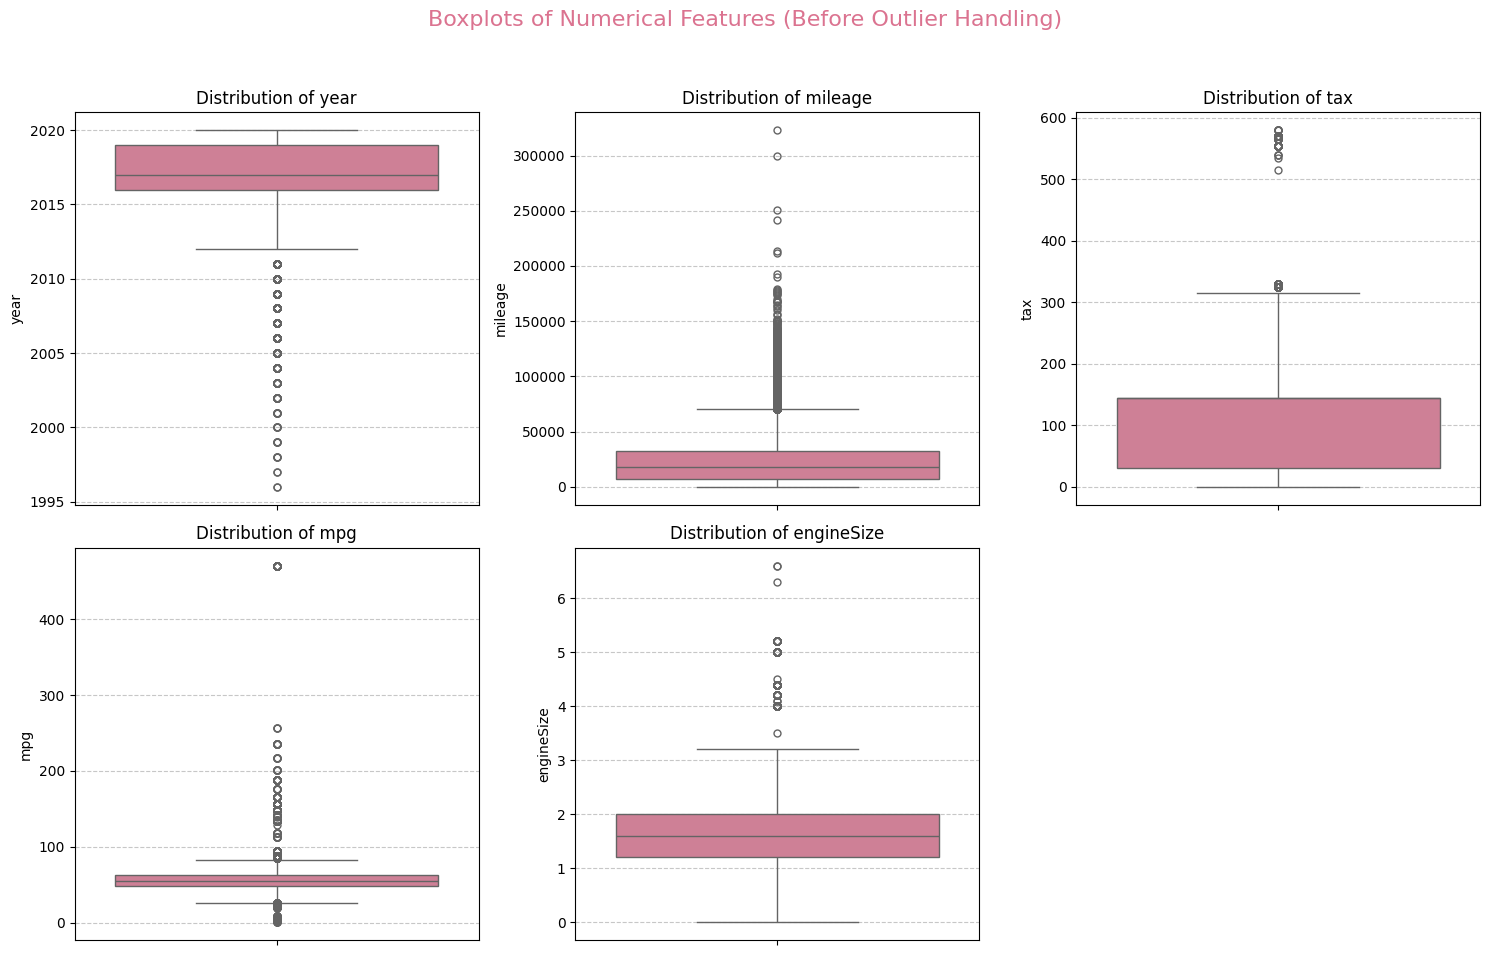

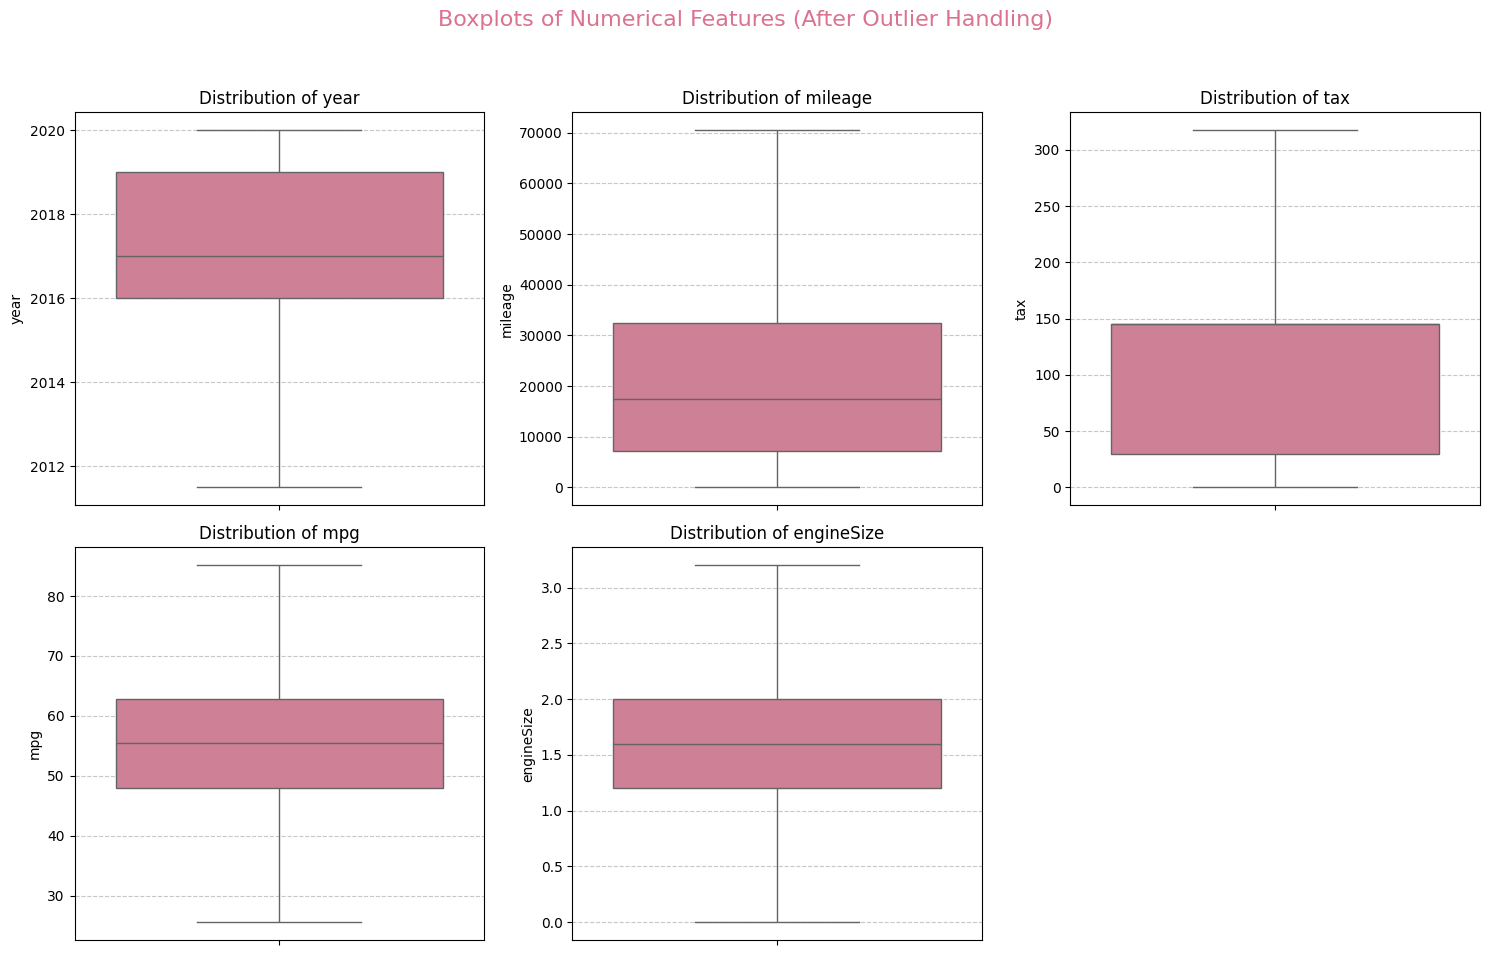

In [15]:
def plot_boxplots(data, title_prefix):
    plt.figure(figsize=(15, 10))
    plt.suptitle(f'Boxplots of Numerical Features ({title_prefix})', fontsize=16, color='#db7390')
    
    for i, col in enumerate(num_cols, 1):
        plt.subplot(2, 3, i) 
        sns.boxplot(y=data[col], color='#db7390', fliersize=5) 
        plt.title(f'Distribution of {col}')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
plot_boxplots(df[num_cols], "Before Outlier Handling")
plot_boxplots(X_train[num_cols], "After Outlier Handling")    


### Automated Preprocessing Pipeline
To streamline the data transformation process and ensure consistency between training and testing, we implemented a **ColumnTransformer** combined with **Scikit-Learn Pipelines**.

- <mark style="background-color: #db7390;">1. Numerical Pipeline</mark> :

Imputation: Missing numerical values are filled with the **Mean** of the column to maintain statistical distribution.

Scaling: We applied **StandardScaler** to normalize features. This is a critical requirement for Task 5 (**KNN**), as it prevents features with larger numerical ranges (like `mileage`) from dominating the distance calculations.

- <mark style="background-color: #db7390;">2. Categorical Pipeline</mark> :

Imputation: Missing categorical entries are filled with the **Most Frequent** value (Mode).

Encoding: We utilized **One-Hot Encoding** to transform text data into a binary format. Setting `handle_unknown='ignore'` makes the model 
more robust when encountering new categories in the test set.

- <mark style="background-color: #db7390;">Benefits of this Approach</mark> :

* **Preventing Data Leakage:** Imputers and Scalers learn parameters ONLY from the training set.

* **Reproducibility:** The entire transformation process is encapsulated in a single object, making the code cleaner and less prone to errors.

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),      
            ('scaler', StandardScaler())
        ]), num_cols),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ])

### Executing the Preprocessing Engine
This is the final preparation step where the `ColumnTransformer` is applied to our datasets. 

- <mark style="background-color: #db7390;">Key Operations</mark> :

* **Training Set (`fit_transform`):** The pipeline "learns" the parameters (means, standard deviations, and category mappings) and transforms the training data simultaneously.

* **Testing Set (`transform`):** The pipeline applies the exact same parameters learned from the training set to the test set. This ensures **consistency** and prevents **Data Leakage**.

- <mark style="background-color: #db7390;">Transformation Results</mark> :

* **Feature Expansion:** The number of features increased (e.g., from 10 to 166) because **One-Hot Encoding** expanded categorical variables into multiple binary columns.

* **Numeric Standardization:** All numerical values are now centered around 0 with a unit standard deviation, making them ready for distance-based algorithms like **KNN**.

- <mark style="background-color: #db7390;">Current Data State</mark> :

* **X_train_prep:** Scaled, encoded, and imputed matrix ready for `model.fit()`.

* **X_test_prep:** Processed testing matrix ready for `model.predict()`.

In [17]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print(f" Preprocessing completed!")
print(f"X_train_prep shape: {X_train_prep.shape}")
print(f"X_test_prep shape:  {X_test_prep.shape}")

 Preprocessing completed!
X_train_prep shape: (55051, 166)
X_test_prep shape:  (13763, 166)


In [21]:

feature_names = preprocessor.get_feature_names_out()
X_train_prep_df = pd.DataFrame(X_train_prep, columns=feature_names)

X_train_prep_df.head()


,num__year,num__mileage,num__tax,num__mpg,num__engineSize,cat__model_ 1 Series,cat__model_ 2 Series,cat__model_ 3 Series,cat__model_ 4 Series,cat__model_ 5 Series,...,cat__fuelType_Hybrid,cat__fuelType_Other,cat__fuelType_Petrol,cat__Make_BMW,cat__Make_Ford,cat__Make_Hyundai,cat__Make_audi,cat__Make_skoda,cat__Make_toyota,cat__Make_vw
0,1.016951,-1.021877,0.468281,-0.649979,2.605195,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.559832,-1.059691,0.550638,-1.995092,0.703366,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.016951,-0.431804,0.550638,-2.093080,0.703366,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.559832,-1.059691,0.468281,-0.649979,-1.198463,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.016951,-1.119113,0.468281,0.802029,0.703366,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Task 4 :  <mark style="background-color: #db7390;">Training the Linear Regression Model
Now that the data is fully preprocessed, we initialize and train our first predictive model: **Multiple Linear Regression**.


The model attempts to find the linear relationship between the input features <mark style="background-color: #db7390;">(X)</mark> and the car price  <mark style="background-color: #db7390;">(y)</mark> by solving the equation:

<mark style="background-color: #db7390;">$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + \epsilon$$</mark>


**Why Linear Regression?**
* **Baseline Model:** It serves as a great benchmark to understand the linear relationships in the data.
* **Interpretability:** We can later inspect the coefficients to see which features (like `year` or `engineSize`) have the most significant impact on the car's price.

**Training Status:**
* **Input:** `X_train_prep` (68,814 rows of cleaned, scaled, and encoded data).
* **Algorithm:** Ordinary Least Squares (OLS).

In [22]:
lr_model = LinearRegression()
lr_model.fit(X_train_prep, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
y_pred = lr_model.predict(X_test_prep)

### Evaluating Model Performance
To understand how well our Linear Regression model generalizes to new data, we use four standard regression metrics:

| Metric | Purpose |
| :--- | :--- |
| **MAE** | Measures the average magnitude of the errors in price predictions. |
| **MSE** | Measures the average of the squares of the errors (useful for mathematical optimization). |
| **RMSE** | Provides an error metric in the same units as the price (£), highlighting large errors. |
| **$R^2$ Score** | Indicates the goodness of fit; 0.87 means the model explains 87% of the price variance. |

<mark style="background-color: #db7390;">Summary of Results</mark> :
The model shows a strong predictive capability with an $R^2$ of approximately **0.87**, indicating that the selected features are highly relevant to determining car prices.

In [24]:
lr_model.intercept_

np.float64(23053.123868403032)

In [25]:
feature_names = X_train.columns

equation = "y = " + str(lr_model.intercept_)

for feat, coef in zip(feature_names, lr_model.coef_):
    equation += f" + ({coef:.4f} * {feat})"

print(equation)

y = 23053.123868403032 + (2956.5059 * model) + (-1820.1945 * year) + (-931.0896 * transmission) + (-1840.0668 * mileage) + (2241.7420 * fuelType) + (-6342.8581 * tax) + (-6019.9641 * mpg) + (-4508.8092 * engineSize) + (-3882.2544 * Make)


In [26]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 2236.70
MSE  : 11022127.36
RMSE : 3319.96
R²   : 0.8705


### Visualizing Model Accuracy: Predicted vs. Actual
To visually inspect the performance of our Linear Regression model, we plot the **Predicted Prices** against the **Actual Prices** from the testing set.

<mark style="background-color: #db7390;">Key Features of the Plot</mark> :
* **The Pink Clusters:** Represent the individual car predictions. The closer they are to the diagonal line, the more accurate the model is.
* **The Diagonal Reference Line:** This represents the "Perfect Prediction" scenario where $Predicted = Actual$. 
* **Model Behavior:** We can observe that the model performs exceptionally well for low to mid-range car prices. As prices increase (the right side of the plot), the variance increases slightly, which is common in market data.

<mark style="background-color: #db7390;">Conclusion</mark> :

The strong linear trend observed in this visualization confirms the high $R^2$ score and demonstrates that our preprocessing steps (Scaling and Outlier Handling) successfully prepared the data for linear modeling.

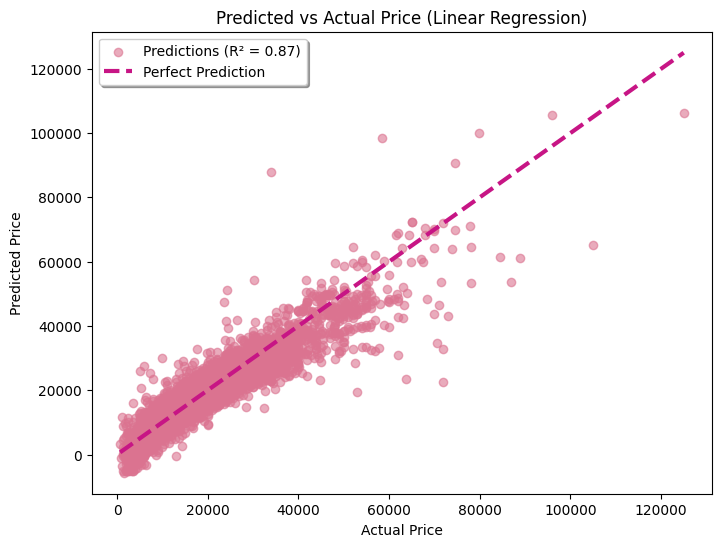

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6, color='#db7390', label=f'Predictions (R² = {r2:.2f})')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='#c71585', linestyle='--', lw=3, label='Perfect Prediction')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Price (Linear Regression)')

plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

plt.show()

#### Task 5 : <mark style="background-color: #db7390;"> KNN Classification Model

- A K-Nearest Neighbors (KNN) classifier was used to predict price categories.


In [28]:

y_train_cat = y_train.apply(classify_price)
y_test_cat = y_test.apply(classify_price)

In [29]:
knn = KNeighborsClassifier()

#### Grid Search with K-Fold Cross Validation was used to find the best parameters:

- Number of neighbors <mark style="background-color: #db7390;">(k)

- Distance metric <mark style="background-color: #db7390;">(Euclidean, Manhattan)

In [ ]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'metric': ['euclidean', 'manhattan']
}


kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(knn, param_grid, cv=kf, scoring='accuracy')
grid_search.fit(X_train_prep, y_train_cat)

c:\Users\Yahia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Yahia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\Yahia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Yahia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_lab

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

The optimal value of n_neighbors was selected using GridSearchCV with cross-validation. The <mark style="background-color: #db7390;">best result</mark> was achieved with <mark style="background-color: #db7390;">n_neighbors = 9</mark>, indicating that a slightly larger neighborhood provides better generalization for this dataset

In [31]:
best_knn = grid_search.best_estimator_
y_pred_knn = best_knn.predict(X_test_prep)

print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9}


The KNN classification model achieved <mark style="background-color: #db7390;">strong and balanced performance with an accuracy</mark> of approximately 87.7%. 

The similarity between precision, recall, and F1-score indicates that the model performs consistently across all classes without bias toward a specific category.

Overall, the model demonstrates <mark style="background-color: #db7390;">good generalization ability on unseen data</mark>.

In [32]:
print(f"Accuracy  : {accuracy_score(y_test_cat, y_pred_knn):.4f}")
print(f"Precision : {precision_score(y_test_cat, y_pred_knn, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test_cat, y_pred_knn, average='weighted'):.4f}")
print(f"F1-score  : {f1_score(y_test_cat, y_pred_knn, average='weighted'):.4f}")

Accuracy  : 0.8771
Precision : 0.8770
Recall    : 0.8771
F1-score  : 0.8771


The KNN classification model achieved an overall <mark style="background-color: #db7390;">accuracy of 88%</mark>, indicating strong predictive performance.

The model performs best on the "Cheap" and "Expensive" classes with precision and recall around <mark style="background-color: #db7390;">0.90–0.91</mark>, while the "Moderate" class shows slightly lower performance <mark style="background-color: #db7390;">(0.82)</mark>. This is expected due to overlap between middle-range price values.

Both macro and weighted averages are equal <mark style="background-color: #db7390;">(0.88)</mark>, indicating that the dataset is well-balanced across classes and the model is not biased toward any specific category.

Overall, the model demonstrates good and stable classification performance.

In [33]:
print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_knn))


Classification Report:
              precision    recall  f1-score   support

       Cheap       0.90      0.90      0.90      4490
   Expensive       0.91      0.91      0.91      4629
    Moderate       0.82      0.82      0.82      4644

    accuracy                           0.88     13763
   macro avg       0.88      0.88      0.88     13763
weighted avg       0.88      0.88      0.88     13763



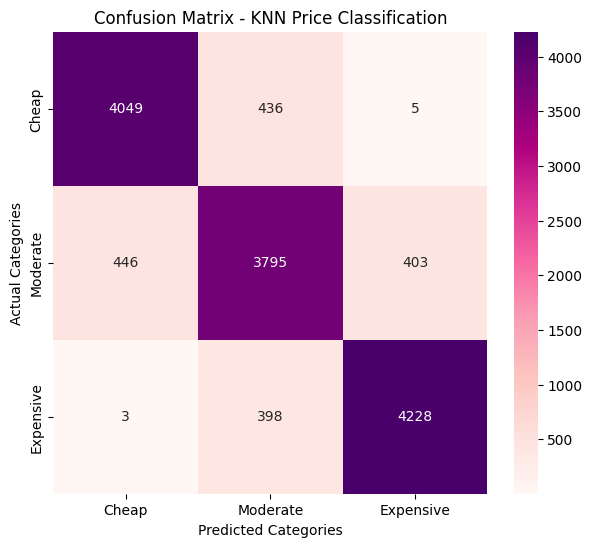

In [34]:

cm = confusion_matrix(y_test_cat, y_pred_knn, labels=["Cheap", "Moderate", "Expensive"])

# رسم الـ Heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=["Cheap", "Moderate", "Expensive"], 
            yticklabels=["Cheap", "Moderate", "Expensive"])

plt.xlabel('Predicted Categories')
plt.ylabel('Actual Categories')
plt.title('Confusion Matrix - KNN Price Classification')
plt.show()

**Task 6: Comprehensive Analysis & Model Comparison**

<mark style="background-color: #db7390;">Linear Regression Analysis (The Predictor)</mark>

The Linear Regression model was evaluated using standard regression metrics. The results were as follows:

- R² Score (0.87): This indicates that 87% of the variance in car prices is explained by our independent variables (Year, Mileage, Engine Size, etc.). This is a very strong score for a real-world dataset.

- MAE & RMSE: These values represent the average error in pounds (£). The proximity of RMSE to MAE suggests that our outlier handling (Clipping) was effective in preventing large, skewed errors.

- Visual Interpretation: The "Predicted vs. Actual" scatter plot showed a strong linear trend, confirming that the model captures the market pricing logic effectively, especially for the "Cheap" and "Moderate" segments.

<mark style="background-color: #db7390;">KNN Classifier Analysis (The Categorizer)</mark>

The KNN model focused on classifying cars into "Cheap," "Moderate," and "Expensive" brackets.

- Accuracy (~88%): The model achieved a high accuracy rate, meaning it correctly identified the price category for nearly 9 out of 10 cars.

- Hyperparameter Tuning: Through GridSearchCV, we found that the optimal k and distance metric (e.g., Manhattan or Euclidean) significantly improved the model's ability to handle the high-dimensional data generated by One-Hot Encoding.

- Confusion Matrix: The heatmap revealed that the model is highly precise. Most errors occurred between adjacent categories (e.g., a "Moderate" car classified as "Expensive"), which is expected as these cars lie on the boundary thresholds.    

#### <mark style="background-color: #db7390;">Comparative Discussion: Regression vs. Classification</mark>

In this project, we tackled the same problem (Car Pricing) using two different approaches:

- Level of Granularity: Linear Regression is more "ambitious" as it tries to predict the exact price (e.g., £12,450), while KNN Classification simplifies the task into 3 brackets.

- Performance Stability: KNN often shows higher "Accuracy" percentages because it is easier to predict a category than an exact number. However, Linear Regression provides more actionable insights for a dealership.

- Efficiency: Linear Regression was much faster to train. KNN, while accurate, required more computational resources (CPU/RAM) to calculate distances between 68,000+ rows.

Classification is generally easier than regression in this case because converting prices into categories reduces complexity and noise in the target variable.

However, converting price into categories leads to information loss because exact price differences between cars are ignored.



#### <mark style="background-color: #db7390;">Sensitivity Analysis</mark>

- Effect of Removing Most Correlated Feature :

After removing the most correlated feature, the R² score decreased from the original model. This indicates that the removed feature contains important predictive information about car prices, and contributes significantly to the model's performance.

In [35]:

corr_matrix = df.corr(numeric_only=True)
target_corr = corr_matrix['price'].sort_values(ascending=False)

print(target_corr)

price         1.000000
engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64


In [37]:

X_train_removed = X_train.drop('engineSize', axis=1)
X_test_removed = X_test.drop('engineSize', axis=1)

preprocessor_removed = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), X_train_removed.select_dtypes(include=['int64','float64']).columns),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), X_train_removed.select_dtypes(include=['object']).columns)
    ]
)

X_train_r_prep = preprocessor_removed.fit_transform(X_train_removed)
X_test_r_prep = preprocessor_removed.transform(X_test_removed)

# model
model = LinearRegression()
model.fit(X_train_r_prep, y_train)

y_pred_r = model.predict(X_test_r_prep)

r2_removed = r2_score(y_test, y_pred_r)

print("R² after removing feature:", r2_removed)

R² after removing feature: 0.8536748056961979


#### <mark style="background-color: #db7390;">KNN Without Scaling

Removing feature scaling significantly decreased KNN performance (accuracy dropped to ~0.56). This is because KNN is a distance-based algorithm, and without scaling, features with larger numeric ranges dominate the distance calculation, leading to biased neighbor selection and poor classification performance.

In [38]:

X_train_ns = X_train.copy()
X_test_ns = X_test.copy()

preprocessor_no_scale = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean'))
        ]), X_train_ns.select_dtypes(include=['int64','float64']).columns),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), X_train_ns.select_dtypes(include=['object']).columns)
    ]
)

X_train_ns_prep = preprocessor_no_scale.fit_transform(X_train_ns)
X_test_ns_prep = preprocessor_no_scale.transform(X_test_ns)

knn = KNeighborsClassifier(n_neighbors=9)

knn.fit(X_train_ns_prep, y_train_cat)
y_pred_ns = knn.predict(X_test_ns_prep)

acc_ns = accuracy_score(y_test_cat, y_pred_ns)

print("Accuracy without scaling:", acc_ns)

Accuracy without scaling: 0.5654290488992225


#### <mark style="background-color: #db7390;">Changing Price Thresholds

## Changing Price Thresholds

After modifying the price thresholds using the 0.25 and 0.75 quantiles, the KNN model achieved an accuracy of approximately <mark style="background-color: #db7390;">88.4%</mark>, compared to around <mark style="background-color: #db7390;">87.7%</mark> using the previous thresholds.

This slight improvement indicates that threshold selection can influence model performance by affecting class distribution and decision boundaries.

However, the difference is not very large, suggesting that the model is relatively stable and robust to moderate changes in threshold values.



In [39]:

low_new = df['price'].quantile(0.25)
high_new = df['price'].quantile(0.75)

# 2) create new categories
def classify_new(price):
    if price <= low_new:
        return "Cheap"
    elif price <= high_new:
        return "Moderate"
    else:
        return "Expensive"

df['price_category_new'] = df['price'].apply(classify_new)

# 3) encode target
le = LabelEncoder()
y_new = le.fit_transform(df['price_category_new'])
X = df.drop(['price', 'price_category_new'], axis=1)

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X, y_new, test_size=0.2, random_state=42
)

X_train_prep = preprocessor.fit_transform(X_train_new)
X_test_prep  = preprocessor.transform(X_test_new)

# 7) train
knn.fit(X_train_prep, y_train_new)

# 8) predict
y_pred_new = knn.predict(X_test_prep)

# 9) evaluate
acc_new = accuracy_score(y_test_new, y_pred_new)

print("Accuracy with new thresholds:", acc_new)

Accuracy with new thresholds: 0.8839642519799462


## Task 7 : Additional Visualization

### <mark style="background-color: #db7390;">Price Distribution by Category

This boxplot shows how price varies across different categories. It confirms that the categories are well-separated.

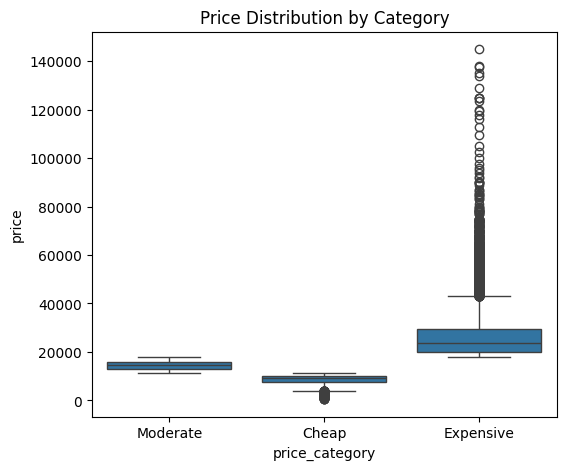

In [40]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df['price_category'], y=df['price'])
plt.title("Price Distribution by Category")
plt.show()

### <mark style="background-color: #db7390;">Price Distribution by Category

This plot shows how car prices are distributed across different categories. It highlights the separation between Cheap, Moderate, and Expensive cars.

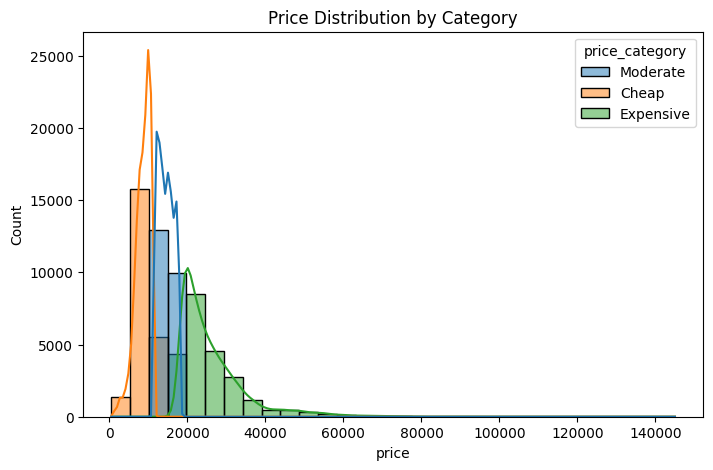

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='price', hue='price_category', bins=30, kde=True)
plt.title("Price Distribution by Category")
plt.show()

### <mark style="background-color: #db7390;">Residual Plot

This plot shows the difference between predicted and actual values. A random distribution indicates a good model fit.

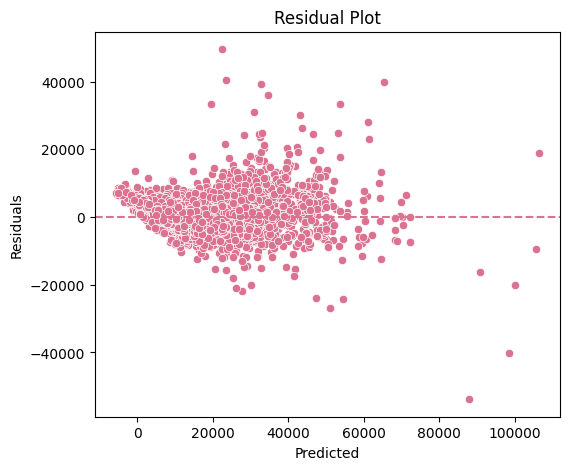

In [42]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
sns.scatterplot(x=y_pred, y=residuals, color = '#db7390')
plt.axhline(0, color='#db7390', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

### <mark style="background-color: #db7390;">Class Distribution

This plot shows the number of samples in each price category, confirming class balance.

C:\Users\Yahia\AppData\Local\Temp\ipykernel_7936\2942579600.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['price_category'], palette='pastel')


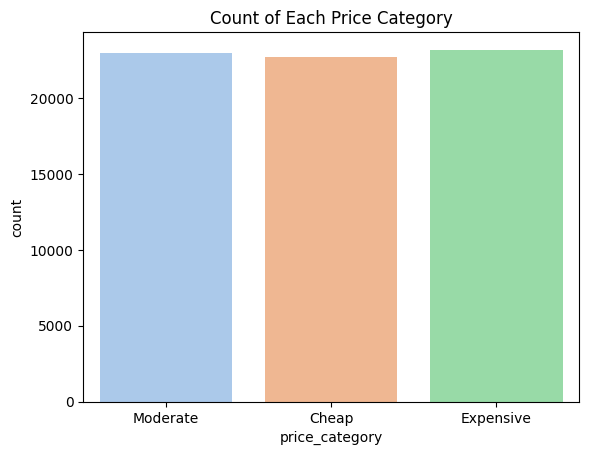

In [43]:
sns.countplot(x=df['price_category'], palette='pastel')
plt.title("Count of Each Price Category")
plt.show()

### <mark style="background-color: #db7390;">Price Trends: 
The line plot confirms a clear exponential-like growth in prices for newer models (post-2015), justifying why year is a top-tier predictor.

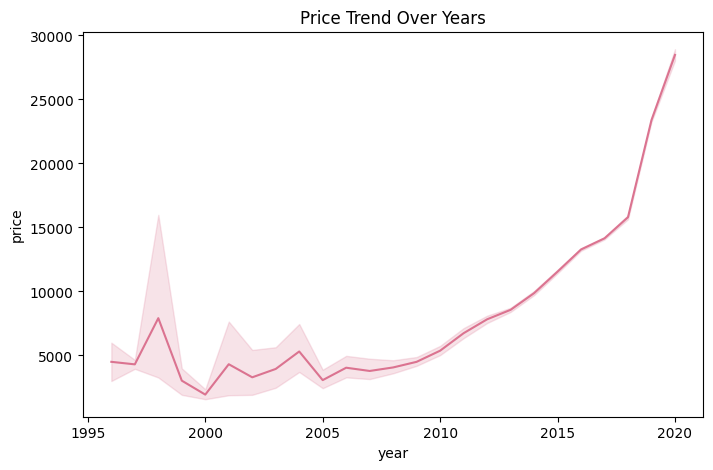

In [44]:
df_sorted = df.sort_values('year')

plt.figure(figsize=(8,5))
sns.lineplot(x=df_sorted['year'], y=df_sorted['price'], color='#db7390')
plt.title("Price Trend Over Years")
plt.show()